In [1]:
# Load in python libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import matplotlib.colors as colors

In [16]:
# Here are the parameters for the specific case this calculation is done for
theta = 0.1 # slope angle
f = 1e-4  # coriolis frequency
Sinf = 1.75  # slope Burger number
Ri_inv = 0.85
N2 = 1e-5 #Sinf**2*f**2/np.tan(theta)**2 # stratification
delta = 0.8  # wave magnitude
Vinf = 0.05  # interior velocity
gamma = (1+(1-Ri_inv**(-1))*Sinf**2)*(1+Sinf**2)**(-1)  # stratification parameter
lmbd = N2*gamma*np.tan(theta)/(f*np.cos(theta))  # geostrophic shear
h = Vinf/lmbd  # boundary layer height
fstar = f*np.cos(theta)*(1+Sinf**2)**(0.5)  # modified inertial frequency
beta = (1+Sinf**2)**(0.5)  # beta (portion of modified inertial frequency that modifies it)

In [17]:
fstar

0.00020054950102755233

In [18]:
# (3-Sinf**2)/(3*(1+Sinf**2))

In [19]:
# _height_47.34008467018973_interior_velocity_0.1_visc_1.0e-5_Sinf_2.0000647056909204_gamma_0.3339849703299162_theta_3.619_f_0.0001_N2_1.0e-5.nc

In [20]:
# # file = "flow_fields_height_130.4272905213473_interior_velocity_0.1_visc_1.0e-5_Sinf_0.2500256810990314_gamma_0.9697212409556922_theta_0.453_f_0.0001_N2_1.0e-5.nc"
file = "flow_fields_Sinf_1.75_Ri_inv_0.85_delta_0.8.nc"
ocean_data=xr.open_dataset("/glade/derecho/scratch/knudsenl/data/new_data/final_draft/"+file).chunk(time=1)#.isel(time=slice(0,4000)) #i=103
seconds = ocean_data.time/pd.Timedelta("1s")
ocean_data = ocean_data.assign_coords(time = ('time',seconds.data))

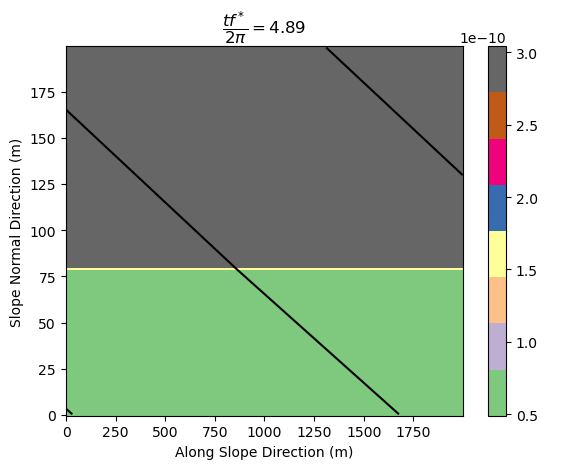

In [4]:
# Plots the total potential vorticity of the flow
q = 100
upper_limit = -1

tm = str(round(ocean_data.time[q].values*fstar/(2*np.pi),2))
(ocean_data.PV).isel(time=q).isel(zF=slice(0,upper_limit)).plot(cbar_kwargs={'label': " "},cmap="Accent") # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=q,yC=0,zC=slice(0,upper_limit)).plot.contour(colors="k")
# xr.plot.contour(bt.isel(time=q,yC=0,zC=slice(0,66)),x=bt.dims[3],y=bt.dims[1],levels=10)#.plot.contour(cmap="ocean",levels= 10)
plt.title(r"$\dfrac{tf^*}{2\pi}=$"+str(tm))
plt.xlabel("Along Slope Direction (m)")
plt.ylabel("Slope Normal Direction (m)")
plt.hlines(361.392814588024,xmin=0,xmax=2000,linestyles="--",color="grey")
# xr.plot.contour(b[q,:,:,0],levels=20,cmap="gray")
# # plt.title("Small Pertubations w/0 Background")
# plt.gca().set_aspect(4.5)
# plt.savefig("vvelocity_"+tm+".png")
plt.show()

In [5]:
ocean_data.zC

<xarray.DataArray 'zC' (zC: 256)> Size: 2kB
array([  0.390625,   1.171875,   1.953125, ..., 198.046875, 198.828125,
       199.609375])
Coordinates:
  * zC       (zC) float64 2kB 0.3906 1.172 1.953 2.734 ... 198.0 198.8 199.6
Attributes:
    units:      m
    long_name:  Locations of the cell centers in the z-direction.

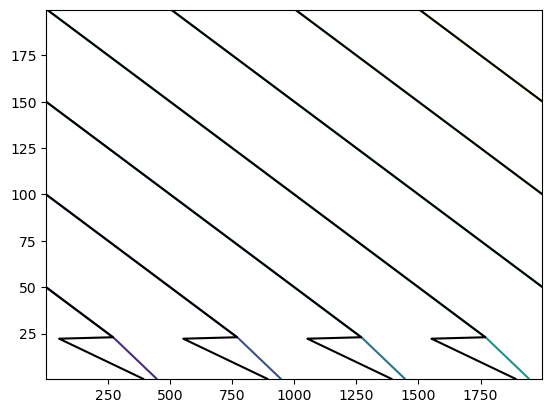

In [6]:
x = np.array([ocean_data.xC.to_numpy()]).T*np.ones((1024,256))
z = (np.array([ocean_data.zC.to_numpy()])*np.ones((1024,256)))
B = N2*(theta*x+z)+N2*gamma*(h-z)*np.heaviside(h-z,1)
B2 = N2*(theta*x+2*z)*np.heaviside(h-z,1)+2*N2*gamma*(h-z)*np.heaviside(h-z,1) + N2*(theta*x+z)*np.heaviside(z-h,1)
# B2 = N2*(theta*x+z)*np.heaviside(z-h,1)
plt.contour(x,z,B)
plt.contour(x,z,B2,colors="k")

In [7]:
B

array([[5.36156394e-05, 5.97252659e-05, 6.58348925e-05, ...,
        1.98144531e-03, 1.98925781e-03, 1.99707031e-03],
       [5.55687644e-05, 6.16783909e-05, 6.77880175e-05, ...,
        1.98339844e-03, 1.99121094e-03, 1.99902344e-03],
       [5.75218894e-05, 6.36315159e-05, 6.97411425e-05, ...,
        1.98535156e-03, 1.99316406e-03, 2.00097656e-03],
       ...,
       [2.04775626e-03, 2.05386589e-03, 2.05997552e-03, ...,
        3.97558594e-03, 3.98339844e-03, 3.99121094e-03],
       [2.04970939e-03, 2.05581902e-03, 2.06192864e-03, ...,
        3.97753906e-03, 3.98535156e-03, 3.99316406e-03],
       [2.05166251e-03, 2.05777214e-03, 2.06388177e-03, ...,
        3.97949219e-03, 3.98730469e-03, 3.99511719e-03]])

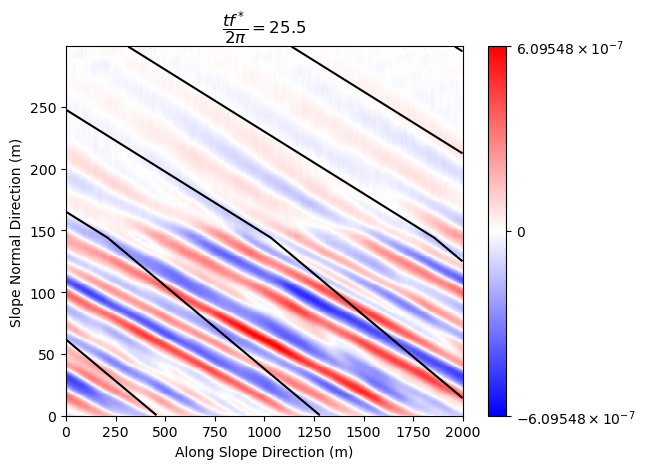

In [23]:
# Plots the velocity
q = 510
upper_limit = -1

tm = str(round(ocean_data.time[q].values*fstar/(2*np.pi),2))
(ocean_data.v).isel(time=q,zC=slice(0,upper_limit)).plot(cbar_kwargs={'label': " "},cmap="bwr",norm=colors.SymLogNorm(linthresh=1e-4)) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=q,yC=0,zC=slice(0,upper_limit)).plot.contour(colors="k")
# xr.plot.contour(bt.isel(time=q,yC=0,zC=slice(0,66)),x=bt.dims[3],y=bt.dims[1],levels=10)#.plot.contour(cmap="ocean",levels= 10)
plt.title(r"$\dfrac{tf^*}{2\pi}=$"+str(tm))
plt.xlabel("Along Slope Direction (m)")
plt.ylabel("Slope Normal Direction (m)")
# plt.hlines(103,xmin=0,xmax=2000,linestyles="--",color="grey")
# xr.plot.contour(b[q,:,:,0],levels=20,cmap="gray")
# # plt.title("Small Pertubations w/0 Background")
# plt.gca().set_aspect(4.5)
# plt.savefig("vvelocity_"+tm+".png")
plt.show()

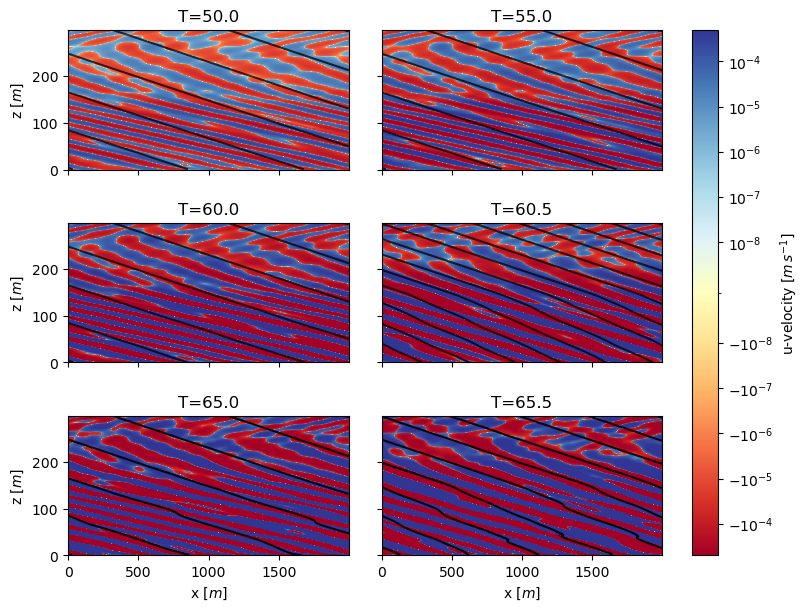

In [24]:
# Create Figure that plots velocity field over time
upper_limit = -1
isopycnal_numbers = 15
t1 = 1000
t2 = 1100
t3 = 1200
t4 = 1210
t5 = 1300
t6 = 1310
v_max = 5e-4
lin_thresh = 1e-8
c_map = "RdYlBu"
fig, axs = plt.subplots(3, 2,sharex=True,sharey=True,figsize=(8,6),layout="constrained")
# fig, axs = plt.subplot_mosaic([["(a.)", "(b.)"], ["(c.)", "(d.)"],["(e.)","(f.)"]],sharex=True,sharey=True,figsize=(8,6),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[0,1],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t3,zC=slice(0,upper_limit)).plot(ax=axs[1,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t3,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,0].set(title=r"T="+str(round(ocean_data.time[t3].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t4,zC=slice(0,upper_limit)).plot(ax=axs[1,1], label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True)
(ocean_data.B+ocean_data.ba).isel(time=t4,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,1].set(title=r"T="+str(round(ocean_data.time[t4].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t5,zC=slice(0,upper_limit)).plot(ax=axs[2,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t5,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[2,0],colors="k",levels=isopycnal_numbers,alpha=0.9)
axs[2,0].set(title=r"T="+str(round(ocean_data.time[t5].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel="z [$m$]")
im = ocean_data.u.isel(time=t6,zC=slice(0,upper_limit)).plot(ax=axs[2,1], label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True)
(ocean_data.B+ocean_data.ba).isel(time=t6,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[2,1],colors="k",levels=isopycnal_numbers,alpha=0.9)
axs[2,1].set(title=r"T="+str(round(ocean_data.time[t6].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
fig.colorbar(im, ax=axs,label="u-velocity [$m\,s^{-1}$]",ticks=[1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,1e-7,-1e-7,1e-8,-1e-8]) 
# plt.savefig("uvelocity_S_1_gamma_l_delta_0_5_linthresh_10_7.jpeg")


In [ ]:
# Create Figure that plots velocity field over time
upper_limit = -1
isopycnal_numbers = 15
t1 = 1200
t2 = 1210
t3 = 1300
t4 = 1310
v_max = 5e-4
lin_thresh = 1e-8
c_map = "RdYlBu"
fig, axs = plt.subplots(2, 2,sharex=True,sharey=True,figsize=(8,6),layout="constrained")
# fig, axs = plt.subplot_mosaic([["(a.)", "(b.)"], ["(c.)", "(d.)"],["(e.)","(f.)"]],sharex=True,sharey=True,figsize=(8,6),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[0,1],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t3,zC=slice(0,upper_limit)).plot(ax=axs[1,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t3,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,0].set(title=r"T="+str(round(ocean_data.time[t3].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel="z [$m$]")
im = ocean_data.u.isel(time=t4,zC=slice(0,upper_limit)).plot(ax=axs[1,1], label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True)
(ocean_data.B+ocean_data.ba).isel(time=t4,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,1].set(title=r"T="+str(round(ocean_data.time[t4].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
fig.colorbar(im, ax=axs,label="u-velocity [$m\,s^{-1}$]",ticks=[1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,1e-7,-1e-7,1e-8,-1e-8]) 
# plt.savefig("uvelocity_S_1_gamma_l_delta_0_5_linthresh_10_7.jpeg")


In [ ]:
ocean_data.u.isel(time=-1400,zC=slice(0,upper_limit)).plot(label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max),rasterized=True) # cmap="Accent"zC=slice(0,70)

In [ ]:
# Same as before but with four plots only
upper_limit = -1
isopycnal_numbers = 15
t1 = 200
t2 = 210 
t3 = 300
t4 = 310
v_max = 1e-4
lin_thresh = 1e-7
c_map = "RdYlBu"
fig, axs = plt.subplots(2, 2,sharex=True,sharey=True,figsize=(8,4),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max)) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[0,1],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max)) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t3,zC=slice(0,upper_limit)).plot(ax=axs[1,0],label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max)) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t3,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,0].set(title=r"T="+str(round(ocean_data.time[t3].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel="z [$m$]")
im = ocean_data.u.isel(time=t4,zC=slice(0,upper_limit)).plot(ax=axs[1,1], label=" ",add_colorbar=False,cmap=c_map,norm=colors.SymLogNorm(linthresh=lin_thresh,vmin=-v_max,vmax=v_max))
(ocean_data.B+ocean_data.ba).isel(time=t4,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,1].set(title=r"T="+str(round(ocean_data.time[t4].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
fig.colorbar(im, ax=axs,label="u-velocity [$m\,s^{-1}$]",ticks=[1e-2,-1e-2,1e-3,-1e-3,1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,0]) # ,ticks=[1e-2,-1e-2,1e-3,-1e-3,1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,1e-7,-1e-7]
# plt.savefig("uvelocity_S_1_Riinv_0_95_delta_0_8_linear_phase.pdf")


In [ ]:
# PLot of the finite amplitude phase
upper_limit = -1
isopycnal_numbers = 15
t1 = 300
t2 = 310
t3 = 330
t4 = 340
t5 = 360
t6 = 370
v_max = 1e-3
c_map = "RdYlBu"
fig, axs = plt.subplots(3, 2,sharex=True,sharey=True,figsize=(8,6),layout="constrained")
# fig, axs = plt.subplot_mosaic([["(a.)", "(b.)"], ["(c.)", "(d.)"],["(e.)","(f.)"]],sharex=True,sharey=True,figsize=(8,6),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0,0],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[0,1],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t3,zC=slice(0,upper_limit)).plot(ax=axs[1,0],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t3,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,0].set(title=r"T="+str(round(ocean_data.time[t3].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t4,zC=slice(0,upper_limit)).plot(ax=axs[1,1], label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max)
(ocean_data.B+ocean_data.ba).isel(time=t4,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,1].set(title=r"T="+str(round(ocean_data.time[t4].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t5,zC=slice(0,upper_limit)).plot(ax=axs[2,0],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t5,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[2,0],colors="k",levels=isopycnal_numbers,alpha=0.9)
axs[2,0].set(title=r"T="+str(round(ocean_data.time[t5].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel="z [$m$]")
# ocean_data.v.isel(time=366,zC=slice(0,upper_limit)).plot(ax=axs[1,1],label=" ",add_colorbar=False,cmap="bwr",norm=colors.SymLogNorm(linthresh=1e-4,vmin=-1e-2,vmax=1e-2)) # cmap="Accent"zC=slice(0,70)
im = ocean_data.u.isel(time=t6,zC=slice(0,upper_limit)).plot(ax=axs[2,1], label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max)
(ocean_data.B+ocean_data.ba).isel(time=t6,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[2,1],colors="k",levels=isopycnal_numbers,alpha=0.9)
axs[2,1].set(title=r"T="+str(round(ocean_data.time[t6].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
fig.colorbar(im, ax=axs,label="u-velocity [$m\,s^{-1}$]",ticks=[-5e-3,5e-3,4e-3,-4e-3,3e-3,-3e-3,2e-3,-2e-3,1e-3,-1e-3,0]) # ,ticks=[1e-2,-1e-2,1e-3,-1e-3,1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,1e-7,-1e-7]
# plt.savefig("uvelocity_S_1_gamma_u_delta_0_5_finite_amplitude.pdf")


In [ ]:
# Same as before but with four plots only
upper_limit = -1
isopycnal_numbers = 15
t1 = 340
t2 = 350
t3 = 360
t4 = 370
v_max = 2e-3
c_map = "RdYlBu"
fig, axs = plt.subplots(2, 2,sharex=True,sharey=True,figsize=(8,4),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0,0],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel="z [$m$]")
ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[0,1],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0,1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel=" ",ylabel=" ")
ocean_data.u.isel(time=t3,zC=slice(0,upper_limit)).plot(ax=axs[1,0],label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t3,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,0].set(title=r"T="+str(round(ocean_data.time[t3].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel="z [$m$]")
im = ocean_data.u.isel(time=t4,zC=slice(0,upper_limit)).plot(ax=axs[1,1], label=" ",add_colorbar=False,cmap=c_map,vmin=-1*v_max,vmax=v_max)
(ocean_data.B+ocean_data.ba).isel(time=t4,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1,1],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[1,1].set(title = r"T=" + str(round(ocean_data.time[t4].values*fstar/(2*np.pi),2)), xlabel="x [$m$]", ylabel=" ")
fig.colorbar(im, ax=axs, label = "u-velocity [$m\text{ }s^{-1}$]", ticks = [5e-3, -5e-3, 4e-3, -4e-3, 3e-3, -3e-3, 2e-3, -2e-3, -1e-3, 1e-3, 0])
plt.savefig("uvelocity_S_1_Riinv_0_95_delta_0_8_finite_amplitude.pdf")


In [ ]:
# Plot of only 2 velocity fields
upper_limit = -1
isopycnal_numbers = 15
t1 = 400
t2 = 410
v_max = 1e-5
lin_thresh = 1e-3
c_map = "seismic"
fig, axs = plt.subplots(1, 2,sharex=True,sharey=True,figsize=(8,3),layout="constrained")
ocean_data.u.isel(time=t1,zC=slice(0,upper_limit)).plot(ax=axs[0],label=" ",add_colorbar=False,cmap=c_map,vmin=-v_max,vmax=v_max) # cmap="Accent"zC=slice(0,70)
(ocean_data.B+ocean_data.ba).isel(time=t1,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[0],colors="k",levels=isopycnal_numbers,alpha=0.75)
axs[0].set(title=r"T="+str(round(ocean_data.time[t1].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
im = ocean_data.u.isel(time=t2,zC=slice(0,upper_limit)).plot(ax=axs[1], label=" ",add_colorbar=False,cmap=c_map,vmin=-v_max,vmax=v_max)
(ocean_data.B+ocean_data.ba).isel(time=t2,yC=0,zC=slice(0,upper_limit)).plot.contour(ax=axs[1],colors="k",levels=isopycnal_numbers,alpha=0.9)
axs[1].set(title=r"T="+str(round(ocean_data.time[t2].values*fstar/(2*np.pi),2)),xlabel="x [$m$]",ylabel=" ")
cbar = fig.colorbar(im, ax=axs,label="u-velocity [$m\,s^{-1}$]",ticks=[-5e-6,5e-6,-3e-6,3e-6,-1e-6,1e-6,0]) # ,ticks=[1e-2,-1e-2,1e-3,-1e-3,1e-4,-1e-4,1e-5,-1e-5,1e-6,-1e-6,1e-7,-1e-7]
cbar.set_ticklabels([r"$-5\times 10^{-6}$",r"$5\times 10^{-6}$",r"$-3$",r"$3$",r"$-1$",r"$1$",r"$0$"])
# plt.savefig("uvelocity_S_1_gamma_u_delta_0_5_mag_comparison.pdf")


In [ ]:
#  Generate animation of velocity
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128
# plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, axs = plt.subplots(figsize=(8,4))

frms = 301 #len(ocean_data.u.time[])
def animate(t):
    plt.clf()
    tm = round(ocean_data.time[t+100].data*fstar/(2*np.pi),2)

    # norm = matplotlib.colors.SymLogNorm(linthresh=0.000001,linscale=1,base=10,vmin=ocean_data.v.min(),vmax=10**(-4))
    ocean_data.v.isel(time=t+100,yF=0,zC=slice(0,-1)).plot(add_colorbar=True,cmap='seismic',norm = matplotlib.colors.SymLogNorm(linthresh=10**(-6),linscale=1,base=10,vmin=-10**(-2),vmax=10**(-2)),cbar_kwargs={'label': "v [$m/s$]","fraction":0.0231,'pad':0.04}) # vmin=-0.001,vmax=0.001
    ocean_data.B.isel(time=t+100,yC=0,zC=slice(0,-1)).plot.contour(cmap="k")
    plt.hlines(114.47837535574962,xmin=0,xmax=2000,linestyles="--",color="grey")
    plt.gca().set_aspect(5)
    # plt.figure(figsize=(8,5))
    plt.xlabel("x [m]")
    plt.ylabel("z [m]")
    plt.title("$T=$"+str(tm))

# matplotlib.animation.FuncAnimation(fig, animate, frames=frms)
anim = matplotlib.animation.FuncAnimation(fig, animate, frames=frms)
writervideo = matplotlib.animation.FFMpegWriter(fps=60) 
anim.save('v_base_PSI.gif') 
plt.close()